# OpenOrtho Complete Workflow Demo

This notebook demonstrates the **complete workflow** for downloading orthophotos in Germany:

## Workflow Steps
1. 🔍 **Search for available services** in a specific area
2. 📊 **Explore and select services** (WMS and direct downloads)
3. 🌈 **Download RGB imagery** (natural color)
4. 🌿 **Download CIR imagery** (infrared - vegetation health)
5. 🎨 **Download RGBI imagery** (4-band merged)
6. 📦 **Download via direct file service** (fastest method)
7. 📜 **Download historic imagery** (time-series analysis)
8. 📈 **Visualize and compare** all downloaded imagery

---

## Setup: Import Libraries

In [1]:
import sys
from pathlib import Path
import time

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import numpy as np

# Import contextily for basemaps
try:
    import contextily as ctx
    has_contextily = True
except ImportError:
    print("⚠️  contextily not installed. Install with: pip install contextily")
    has_contextily = False

# Import OpenOrtho components
from orthophotos_downloader.data_scraping.auto_downloader import AutoOrthophotoDownloader
from orthophotos_downloader.wms_catalog.catalog_manager import WMSCatalogManager
from orthophotos_downloader.data_scraping.file_downloader import FileServiceDownloader

DOWNLOAD_MAX_WORKERS = 4  # Parallel threads for tile/file downloads
RGBI_DELIVERY_METHOD = "files"  # Choose 'files', 'wms', or 'auto' for RGBI steps

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 1: Define Area of Interest

📁 Loading area from file: data/TOF/extent_sh.kml
   Reprojected from EPSG:4326 to EPSG:25832
✅ Successfully loaded area from file
   Format: .kml
   Area: ~100.00 km²

📍 Area of Interest Summary:
   Source: File: extent_sh.kml
   Size: 10.00 km × 10.00 km
   Bounding box area: 100.00 km²
   Actual area: ~100.00 km²
   Bounds: (568000, 5963000) to (578000, 5973000)
   CRS: EPSG:25832


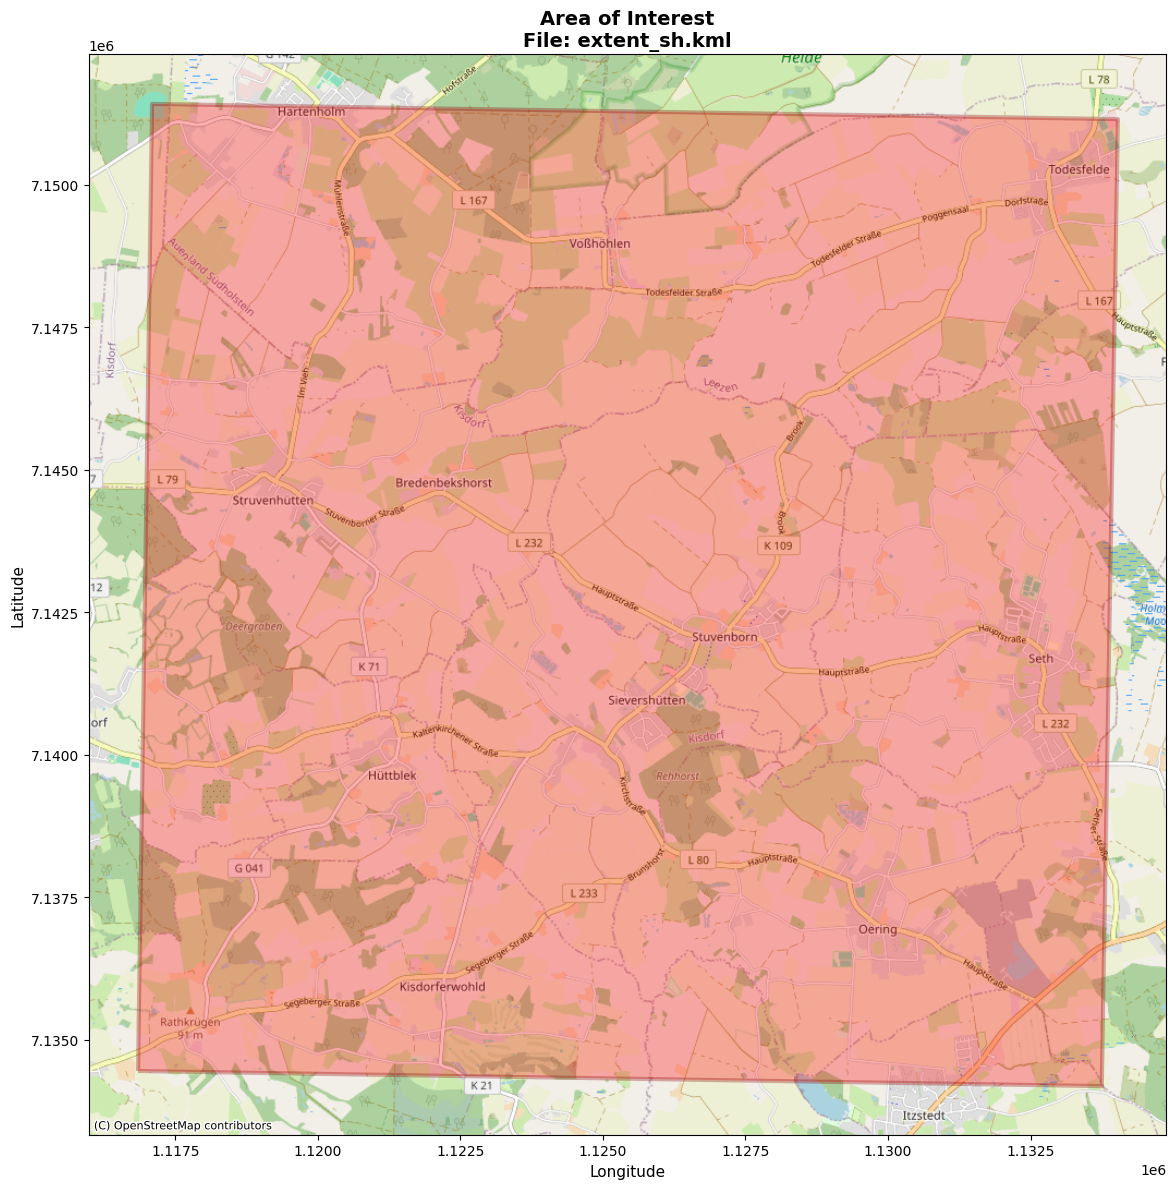


💡 TIP: To change the area, modify the configuration at the top of this cell:
   • AREA_FILE: Path to any spatial file (GeoJSON, Shapefile, GeoPackage, KML, etc.)
   • AREA_NAME: Name to search on OpenStreetMap
   • MANUAL_BBOX: Manual coordinates (only if file and name are None)

💡 TIP: For KML files, if you get driver errors, convert to GeoJSON first:
   ogr2ogr -f GeoJSON output.geojson input.kml


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# 🎯 USER CONFIGURATION - Choose ONE option below
# ═══════════════════════════════════════════════════════════════════════════════

# Option 1: LOAD FROM FILE (Recommended - supports any spatial format)
# Set AREA_FILE to the path of your spatial file (GeoJSON, Shapefile, GeoPackage, KML, etc.)
# Leave as None to use other options
AREA_FILE = "data/TOF/extent_sh.kml"  # Example: "./my_area.geojson" or "/path/to/area.shp"

# Option 2: FETCH FROM OPENSTREETMAP
# Set AREA_NAME to fetch boundary from OpenStreetMap
# Leave as None to use other options
AREA_NAME = 'Blankenese'  # Example: 'Berlin', 'München', 'Cologne, Germany'

# Option 3: MANUAL COORDINATES (UTM Zone 32N - EPSG:25832)
# Define a bounding box with west, south, east, north coordinates
# Only used if both AREA_FILE and AREA_NAME are None
MANUAL_BBOX = {
    'west': 356000,
    'south': 5644000,
    'east': 358000,
    'north': 5646000
}

# ═══════════════════════════════════════════════════════════════════════════════
# Area Loading Logic (Don't modify unless you know what you're doing)
# ═══════════════════════════════════════════════════════════════════════════════

import requests
from shapely.geometry import shape
from shapely.ops import transform
import pyproj

area_gdf = None
area_source = None

# Option 1: Try loading from file first
if AREA_FILE is not None:
    print(f"📁 Loading area from file: {AREA_FILE}")
    try:
        from pathlib import Path
        area_file_path = Path(AREA_FILE)
        
        if not area_file_path.exists():
            print(f"❌ Error: File not found: {AREA_FILE}")
        else:
            # Special handling for KML files (enable LIBKML driver)
            if area_file_path.suffix.lower() in ['.kml', '.kmz']:
                try:
                    # Try with LIBKML driver first (better support)
                    import fiona
                    fiona.drvsupport.supported_drivers['LIBKML'] = 'rw'
                    area_gdf = gpd.read_file(AREA_FILE, driver='LIBKML')
                except Exception as e1:
                    try:
                        # Fallback to KML driver
                        fiona.drvsupport.supported_drivers['KML'] = 'rw'
                        area_gdf = gpd.read_file(AREA_FILE, driver='KML')
                    except Exception as e2:
                        # Final fallback: try default (no driver specification)
                        print(f"   ⚠️  KML/LIBKML drivers not available, trying default reader...")
                        try:
                            area_gdf = gpd.read_file(AREA_FILE)
                        except Exception as e3:
                            raise Exception(
                                f"Could not read KML file. Install GDAL with KML support:\n"
                                f"   conda install -c conda-forge gdal libkml\n"
                                f"   or convert your KML to GeoJSON first:\n"
                                f"   ogr2ogr -f GeoJSON output.geojson input.kml"
                            )
            else:
                # Standard file formats (GeoJSON, Shapefile, GeoPackage, etc.)
                area_gdf = gpd.read_file(AREA_FILE)
            
            # If multiple features, use the union of all geometries
            if len(area_gdf) > 1:
                print(f"   Found {len(area_gdf)} features - using union of all geometries")
                area_geom = area_gdf.geometry.unary_union
                area_gdf = gpd.GeoDataFrame([1], geometry=[area_geom], crs=area_gdf.crs)
            
            # Reproject to EPSG:25832 if needed
            if area_gdf.crs is None:
                print(f"   ⚠️  No CRS defined in file, assuming EPSG:4326 (WGS84)")
                area_gdf = area_gdf.set_crs("EPSG:4326")
            
            if area_gdf.crs != "EPSG:25832":
                original_crs = area_gdf.crs
                area_gdf = area_gdf.to_crs("EPSG:25832")
                print(f"   Reprojected from {original_crs} to EPSG:25832")
            
            area_source = f"File: {area_file_path.name}"
            print(f"✅ Successfully loaded area from file")
            print(f"   Format: {area_file_path.suffix}")
            print(f"   Area: ~{area_gdf.geometry[0].area / 1_000_000:.2f} km²")
            
    except Exception as e:
        print(f"❌ Error loading file: {e}")
        print("   Falling back to other options...")
        area_gdf = None

# Option 2: Try OpenStreetMap if no file was loaded
if area_gdf is None and AREA_NAME is not None:
    print(f"🌐 Fetching boundary from OpenStreetMap: {AREA_NAME}")
    
    nominatim_url = "https://nominatim.openstreetmap.org/search"
    params = {
        'q': AREA_NAME,
        'format': 'json',
        'polygon_geojson': 1,
        'limit': 1
    }
    
    headers = {
        'User-Agent': 'OpenOrtho-Downloader/1.0'
    }
    
    try:
        response = requests.get(nominatim_url, params=params, headers=headers)
        response.raise_for_status()
        data = response.json()
        
        if data and len(data) > 0:
            geojson = data[0]['geojson']
            
            # Create shapely geometry from GeoJSON
            area_geom = shape(geojson)
            
            # Transform from WGS84 (EPSG:4326) to UTM Zone 32N (EPSG:25832)
            project = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:25832', always_xy=True)
            area_geom_utm = transform(project.transform, area_geom)
            
            area_gdf = gpd.GeoDataFrame([1], geometry=[area_geom_utm], crs="EPSG:25832")
            area_source = f"OpenStreetMap: {data[0]['display_name']}"
            
            print(f"✅ Successfully retrieved boundary from OpenStreetMap")
            print(f"   Type: {data[0]['type']}")
            print(f"   Display name: {data[0]['display_name']}")
            print(f"   Area: ~{area_geom_utm.area / 1_000_000:.2f} km²")
        else:
            print(f"⚠️  Could not find '{AREA_NAME}' on OpenStreetMap")
            area_gdf = None
            
    except Exception as e:
        print(f"⚠️  Error fetching from OpenStreetMap: {e}")
        area_gdf = None

# Option 3: Fall back to manual coordinates
if area_gdf is None:
    print("📍 Using manual bounding box coordinates")
    west = MANUAL_BBOX['west']
    south = MANUAL_BBOX['south']
    east = MANUAL_BBOX['east']
    north = MANUAL_BBOX['north']
    
    bbox = box(west, south, east, north)
    area_gdf = gpd.GeoDataFrame([1], geometry=[bbox], crs="EPSG:25832")
    area_source = f"Manual bbox: ({west}, {south}) to ({east}, {north})"
    
    print(f"✅ Created area from manual coordinates")
    print(f"   Area: {(east-west) * (north-south) / 1_000_000:.2f} km²")

# Display final area information
bounds = area_gdf.total_bounds
west, south, east, north = bounds

print(f"\n" + "="*80)
print(f"📍 Area of Interest Summary:")
print(f"   Source: {area_source}")
print(f"   Size: {(east-west)/1000:.2f} km × {(north-south)/1000:.2f} km")
print(f"   Bounding box area: {(east-west) * (north-south) / 1_000_000:.2f} km²")
print(f"   Actual area: ~{area_gdf.geometry[0].area / 1_000_000:.2f} km²")
print(f"   Bounds: ({west:.0f}, {south:.0f}) to ({east:.0f}, {north:.0f})")
print(f"   CRS: {area_gdf.crs}")
print("="*80)

# Visualize the area
fig, ax = plt.subplots(figsize=(12, 12))

if has_contextily:
    # Convert to Web Mercator for basemap
    area_web = area_gdf.to_crs(epsg=3857)
    area_web.plot(ax=ax, facecolor='red', edgecolor='darkred', alpha=0.3, linewidth=3)
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom='auto')
    ax.set_title(f'Area of Interest\n{area_source}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
else:
    area_gdf.plot(ax=ax, facecolor='lightblue', edgecolor='blue', linewidth=2)
    ax.set_title(f'Area of Interest\n{area_source}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Easting (m)', fontsize=11)
    ax.set_ylabel('Northing (m)', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 TIP: To change the area, modify the configuration at the top of this cell:")
print("   • AREA_FILE: Path to any spatial file (GeoJSON, Shapefile, GeoPackage, KML, etc.)")
print("   • AREA_NAME: Name to search on OpenStreetMap")
print("   • MANUAL_BBOX: Manual coordinates (only if file and name are None)")
print("\n💡 TIP: For KML files, if you get driver errors, convert to GeoJSON first:")
print("   ogr2ogr -f GeoJSON output.geojson input.kml")

## Step 2: Search for Available Services

Let's search the catalog to find **all available services** for our area.

In [3]:
# Initialize catalog manager
catalog = WMSCatalogManager()

# Initialize auto downloader to detect which state(s) we're in
downloader = AutoOrthophotoDownloader(grid_spacing=1000)
intersecting_states = downloader.detect_intersecting_states(area_gdf)

print("🎯 Detected State(s):")
for state_name, state_code, _ in intersecting_states:
    print(f"   {state_name} ({state_code})")

# Get the primary state (first one)
# Note: detect_intersecting_states returns (state_name, state_code, intersection)
primary_state_name = intersecting_states[0][0]
primary_state_code = intersecting_states[0][1]

print(f"\n🔍 Searching catalog for services in {primary_state_name}...\n")

# Search for all services in the detected state
state_services = catalog.filter_services(state_code=primary_state_code)

print(f"📊 Found {len(state_services)} services in {primary_state_name}\n")

# Categorize services
current_services = [s for s in state_services if s.year == 'latest' or s.year == 'current']
historic_services = [s for s in state_services if s.year not in ['latest', 'current']]
file_services = [s for s in state_services if s.has_files()]

print(f"📦 Service Categories:")
print(f"   Current/Latest: {len(current_services)} services")
print(f"   Historic: {len(historic_services)} services")
print(f"   Direct file downloads: {len(file_services)} services")

# Show available image types and resolutions
image_types = catalog.get_image_types_for_state(primary_state_code)
resolutions = catalog.get_resolutions_for_state(primary_state_code)

print(f"\n🌈 Available Image Types: {', '.join(image_types)}")
print(f"📏 Available Resolutions: {', '.join(f'{r}m (DOP{int(r*100)})' for r in sorted(resolutions))}")

[2025-11-03 17:57:03 - INFO - orthophotos_downloader.wms_catalog.catalog_manager] Loaded 554 WMS services from catalog
[2025-11-03 17:57:03 - INFO - orthophotos_downloader.wms_catalog.catalog_manager] Loaded 554 WMS services from catalog
[2025-11-03 17:57:03 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Loading German federal states from https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json
[2025-11-03 17:57:04 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 1 intersecting states: ['Schleswig-Holstein']
🎯 Detected State(s):
   Schleswig-Holstein (SH)

🔍 Searching catalog for services in Schleswig-Holstein...

📊 Found 10 services in Schleswig-Holstein

📦 Service Categories:
   Current/Latest: 2 services
   Historic: 8 services
   Direct file downloads: 5 services

🌈 Available Image Types: RGB, RGBI
📏 Available Resolutions: 0.2m (DOP20)


## Step 3: List All Available Services

Let's see **all available services** for our area and select which ones to download.

In [4]:
# Use Service Discovery to find services that actually work for this area
from orthophotos_downloader.wms_catalog.service_discovery import ServiceDiscovery

print(f"🔍 Discovering services for area...\n")
print(f"   Testing services to verify availability...\n")

# Initialize service discovery
discovery = ServiceDiscovery()

# Discover services with coverage check
discovery_result = discovery.discover_services_for_area(
    area_polygon=area_gdf.geometry[0],
    intersecting_states=intersecting_states,
    verify_coverage=True,  # Enable availability testing
    image_type=None,  # Get all types
    max_workers=10  # Fast parallel verification
)

# Get available services
available_services = discovery_result['recommended']

print(f"✅ Discovery Complete!\n")
print(f"📊 Results:")
print(f"   Candidate services: {discovery_result['summary']['total_candidates']}")
print(f"   Available services: {len(available_services)}")
print(f"   Not available: {len(discovery_result['verification']['no_coverage'])}")

if discovery_result['verification']['cached_count'] > 0:
    print(f"   📦 Used {discovery_result['verification']['cached_count']} cached results")
    print(f"   🔄 Newly verified: {discovery_result['verification']['newly_verified']}")

# Show available services
print(f"\n📋 Available Services:\n")
print(f"{'Type':<6} {'Year':<12} {'Res':<8} {'Files':<6} {'Date':<12} {'ID':<40}")
print("=" * 95)

for service in available_services:
    files = '✅' if service.has_files() else '❌'
    year = str(service.year)[:12]  # Allow for longer year strings like '2012-2025'
    
    # Get acquisition date if available from verification
    date_str = 'Unknown'
    if hasattr(service, '_verification_result') and service._verification_result:
        acq_date = service._verification_result.get('acquisition_date')
        if acq_date:
            date_str = acq_date[:10]  # YYYY-MM-DD format
    
    print(f"{service.type:<6} {year:<12} {service.resolution}m    {files:<6} {date_str:<12} {service.id:<40}")

# Update state_services to only include available ones
state_services = available_services

# Categorize services - fix the filtering to handle year ranges
current_services = []
historic_services = []

for s in available_services:
    year_str = str(s.year).lower()
    # Consider services with 'latest', 'current', or year ranges (like '2012-2025') as current
    if year_str in ['latest', 'current'] or '-' in year_str:
        current_services.append(s)
    else:
        historic_services.append(s)

file_services = [s for s in available_services if s.has_files()]

print(f"\n💡 All listed services have been tested and confirmed to work for this area!")
print(f"\n📦 Summary:")
print(f"   Current/Latest: {len(current_services)}")
print(f"   Historic: {len(historic_services)}")
print(f"   File downloads available: {len(file_services)}")

if file_services:
    print(f"\n📦 File Download Services Found:")
    for fs in file_services:
        delivery_info = "GeoJSON-indexed" if hasattr(fs, 'files_index_type') and fs.files_index_type == 'geojson' else "Direct files"
        print(f"   ✅ {fs.id}")
        print(f"      Type: {fs.type}, Year: {fs.year}, Resolution: {fs.resolution}m")
        print(f"      Method: {delivery_info}")
        # Handle None files_url (e.g., for Atom feed services)
        if fs.files_url:
            print(f"      Base URL: {fs.files_url[:60]}..." if len(fs.files_url) > 60 else f"      Base URL: {fs.files_url}")
        else:
            print(f"      Base URL: (Atom feed or dynamic)")
else:
    print(f"\n⚠️  No file download services found for this area")
    print(f"   All {len(available_services)} available services use WMS delivery")

🔍 Discovering services for area...

   Testing services to verify availability...

[2025-11-03 17:57:04 - INFO - orthophotos_downloader.wms_catalog.catalog_manager] Loaded 554 WMS services from catalog
[2025-11-03 17:57:04 - INFO - orthophotos_downloader.wms_catalog.service_discovery] Discovering services for area intersecting states: ['SH']
[2025-11-03 17:57:04 - INFO - orthophotos_downloader.wms_catalog.service_discovery] Found 10 candidate services from catalog
[2025-11-03 17:57:04 - INFO - orthophotos_downloader.wms_catalog.service_discovery] Verifying WMS availability for 10 services...
[2025-11-03 17:57:04 - INFO - orthophotos_downloader.wms_catalog.service_discovery] Using 0 cached results, verifying 10 services
[2025-11-03 17:57:05 - INFO - orthophotos_downloader.data_scraping.file_downloader] Initialized FileServiceDownloader for SH_RGBI_DOP20_current: grid=1000m, crs=EPSG:25832, index=atom, coverage_verification=False
[2025-11-03 17:57:05 - INFO - orthophotos_downloader.data_

In [5]:
# Interactive Service Selection
# Modify these variables to choose which services to download:

# ═══════════════════════════════════════════════════════════════════════════════
# 🎯 USER CONFIGURATION - Change these to select your desired services
# ═══════════════════════════════════════════════════════════════════════════════

# Option 1: AUTO-SELECT (Recommended for beginners)
# Set to True to automatically pick the best available services
AUTO_SELECT = False

# Option 2: MANUAL SELECTION (Advanced users)

RGB_SERVICE_ID = "NW_RGB_DOP20_2022"                             # Change to specific service ID or leave as None
CIR_SERVICE_ID = None      # Change to specific service ID or leave as None
RGBI_SERVICE_ID = "SH_RGBI_DOP20_2023"     # Change to specific service ID or leave as None
HISTORIC_SERVICE_ID = "NW_RGB_DOP40_2020" # Change to specific service ID or leave as None

# Option 3: FILTER-BASED SELECTION (Semi-automatic)
# If AUTO_SELECT is True, these filters will be applied:
PREFER_FILE_DOWNLOADS = True   # Prefer services with direct file downloads (faster)
PREFER_HIGHEST_RESOLUTION = True  # Prefer highest resolution available
HISTORIC_YEAR_RANGE = (1990, 2000)  # Preferred year range for historic imagery

# ═══════════════════════════════════════════════════════════════════════════════
# Selection Logic (Don't modify unless you know what you're doing)
# ═══════════════════════════════════════════════════════════════════════════════

def find_service_by_id(service_id, service_list):
    """Find a service by its ID"""
    if not service_id:
        return None
    for s in service_list:
        if s.id == service_id:
            return s
    print(f"⚠️  Warning: Service '{service_id}' not found in available services")
    return None

def auto_select_service(service_type, current_services, historic_services=None):
    """Automatically select the best service based on user preferences"""
    if service_type == 'HISTORIC' and historic_services:
        candidates = historic_services
        # Try to find service in preferred year range
        year_filtered = [s for s in candidates 
                        if s.year and str(s.year).isdigit() 
                        and HISTORIC_YEAR_RANGE[0] <= int(s.year) <= HISTORIC_YEAR_RANGE[1]]
        if year_filtered:
            candidates = year_filtered
    else:
        candidates = [s for s in current_services if s.type == service_type]
    
    if not candidates:
        return None
    
    # Apply filters
    if PREFER_FILE_DOWNLOADS:
        file_candidates = [s for s in candidates if s.has_files()]
        if file_candidates:
            candidates = file_candidates
    
    if PREFER_HIGHEST_RESOLUTION:
        min_res = min(s.resolution for s in candidates)
        candidates = [s for s in candidates if s.resolution == min_res]
    
    # Return first (or middle for historic)
    if service_type == 'HISTORIC':
        return candidates[len(candidates)//2]
    return candidates[0]

# Perform selection
if AUTO_SELECT:
    print("🤖 AUTO-SELECT Mode: Finding best services based on your preferences...\n")
    rgb_service = auto_select_service('RGB', current_services)
    cir_service = auto_select_service('CIR', current_services)
    rgbi_service = auto_select_service('RGBI', current_services)
    historic_service = auto_select_service('HISTORIC', current_services, historic_services)
else:
    print("👤 MANUAL SELECT Mode: Using your specified service IDs...\n")
    rgb_service = find_service_by_id(RGB_SERVICE_ID, available_services)
    cir_service = find_service_by_id(CIR_SERVICE_ID, available_services)
    rgbi_service = find_service_by_id(RGBI_SERVICE_ID, available_services)
    historic_service = find_service_by_id(HISTORIC_SERVICE_ID, available_services)

# Display selection results
print("✅ Selected Services for Download:\n")

if rgb_service:
    print(f"🌈 RGB Service:")
    print(f"   ID: {rgb_service.id}")
    print(f"   Resolution: {rgb_service.resolution}m (DOP{int(rgb_service.resolution*100)})")
    print(f"   Delivery: {'📦 File downloads' if rgb_service.has_files() else '🌐 WMS tiles'}")
else:
    print("⚠️  No RGB service selected")

if cir_service:
    print(f"\n🌿 CIR Service:")
    print(f"   ID: {cir_service.id}")
    print(f"   Resolution: {cir_service.resolution}m (DOP{int(cir_service.resolution*100)})")
    print(f"   Delivery: {'📦 File downloads' if cir_service.has_files() else '🌐 WMS tiles'}")
else:
    print("⚠️  No CIR service selected")

if rgbi_service:
    print(f"\n🎨 RGBI Service:")
    print(f"   ID: {rgbi_service.id}")
    print(f"   Resolution: {rgbi_service.resolution}m (DOP{int(rgbi_service.resolution*100)})")
    print(f"   Delivery: {'📦 File downloads' if rgbi_service.has_files() else '🌐 WMS tiles'}")
else:
    print("⚠️  No RGBI service selected")

if historic_service:
    print(f"\n📜 Historic Service:")
    print(f"   ID: {historic_service.id}")
    print(f"   Year: {historic_service.year}")
    print(f"   Type: {historic_service.type}")
    print(f"   Resolution: {historic_service.resolution}m (DOP{int(historic_service.resolution*100)})")
    print(f"   Delivery: {'📦 File downloads' if historic_service.has_files() else '🌐 WMS tiles'}")
else:
    print("⚠️  No historic service selected")

print("\n" + "="*80)
print("💡 TIP: To change services:")
print("   • Keep AUTO_SELECT = True and modify the preference filters, OR")
print("   • Set AUTO_SELECT = False and specify exact service IDs from the list above")
print("="*80)

👤 MANUAL SELECT Mode: Using your specified service IDs...

⚠️  Warning: Service 'NW_RGB_DOP20_2022' not found in available services
⚠️  Warning: Service 'NW_RGB_DOP40_2020' not found in available services
✅ Selected Services for Download:

⚠️  No RGB service selected
⚠️  No CIR service selected

🎨 RGBI Service:
   ID: SH_RGBI_DOP20_2023
   Resolution: 0.2m (DOP20)
   Delivery: 📦 File downloads
⚠️  No historic service selected

💡 TIP: To change services:
   • Keep AUTO_SELECT = True and modify the preference filters, OR
   • Set AUTO_SELECT = False and specify exact service IDs from the list above


## Step 4: Download RGB Imagery

RGB imagery shows **natural colors** (Red, Green, Blue) - what you would see with your eyes.

In [11]:
import time

# Create output directory
output_dir = Path("./data/demo_area")
output_dir.mkdir(parents=True, exist_ok=True)

if rgb_service:
    print("📥 Downloading RGB imagery...")
    print(f"   Using service: {rgb_service.id}")
    print(f"   Resolution: {rgb_service.resolution}m\n")
    
    start_time = time.time()
    
    try:
        # Create downloader configured for this specific service
        rgb_downloader = AutoOrthophotoDownloader(
            grid_spacing=1000,
            year=rgb_service.year,
            extract_metadata=True,  # Enable metadata extraction
            max_workers=DOWNLOAD_MAX_WORKERS
        )
        
        # Download RGB images
        rgb_datasets = rgb_downloader.download_rgb_images_auto(
            area_polygon=area_gdf,
            area_name="demo_area",
            out_path=output_dir / "rgb",
            filename_prefix="RGB"
        )
        
        download_time = time.time() - start_time
        
        # List downloaded files
        rgb_files = list((output_dir / "rgb").rglob("*.tiff"))
        total_size = sum(f.stat().st_size for f in rgb_files) / (1024 * 1024)  # MB
        
        print(f"\n✅ RGB Download Complete!")
        print(f"   Files: {len(rgb_files)}")
        print(f"   Time: {download_time:.2f}s")
        print(f"   Size: {total_size:.2f} MB")
        print(f"   Speed: {total_size/download_time:.2f} MB/s")
        print(f"   Location: {output_dir / 'rgb'}")
        
        # Show metadata info
        if rgb_datasets:
            print(f"   📋 Metadata: Service {rgb_service.id}, Year {rgb_service.year}")
        
    except Exception as e:
        print(f"❌ Error downloading RGB: {e}")
        import traceback
        traceback.print_exc()
        rgb_files = []
else:
    print("⚠️  No RGB service available for this state")
    rgb_files = []

📥 Downloading RGB imagery...
   Using service: NW_RGB_DOP20_2022
   Resolution: 0.1m

[2025-11-02 22:44:06 - INFO - orthophotos_downloader.wms_catalog.catalog_manager] Loaded 547 WMS services from catalog
[2025-11-02 22:44:06 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Loading German federal states from https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json
[2025-11-02 22:44:06 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 1 intersecting states: ['Nordrhein-Westfalen']
[2025-11-02 22:44:06 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing Nordrhein-Westfalen (NW)...
[2025-11-02 22:44:06 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Using service: NW_RGB_DOP20_2022 (year: 2022, layer: nw_hist_dop_2022)
[2025-11-02 22:44:06 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Auto-selecting WMSServiceDownloader for NW_RGB_DOP20_2022 (WMS only)
[2025

## Step 5: Download CIR Imagery

CIR (Color Infrared) imagery shows **vegetation health**. Healthy vegetation appears bright red because it reflects infrared light strongly.

In [ ]:
if cir_service:
    print("📥 Downloading CIR imagery...")
    print(f"   Using service: {cir_service.id}")
    print(f"   Resolution: {cir_service.resolution}m\n")
    
    start_time = time.time()
    
    try:
        # Create downloader configured for this specific service
        cir_downloader = AutoOrthophotoDownloader(
            grid_spacing=1000,
            year=cir_service.year,
            extract_metadata=True,  # Enable metadata extraction
            max_workers=DOWNLOAD_MAX_WORKERS
        )
        
        # Download CIR images
        cir_datasets = cir_downloader.download_cir_images_auto(
            area_polygon=area_gdf,
            area_name="demo_area",
            out_path=output_dir / "cir",
            filename_prefix="CIR"
        )
        
        download_time = time.time() - start_time
        
        # List downloaded files
        cir_files = list((output_dir / "cir").rglob("*.tiff"))
        total_size = sum(f.stat().st_size for f in cir_files) / (1024 * 1024)  # MB
        
        print(f"\n✅ CIR Download Complete!")
        print(f"   Files: {len(cir_files)}")
        print(f"   Time: {download_time:.2f}s")
        print(f"   Size: {total_size:.2f} MB")
        print(f"   Speed: {total_size/download_time:.2f} MB/s")
        print(f"   Location: {output_dir / 'cir'}")
        
        # Show metadata info
        if cir_datasets:
            print(f"   📋 Metadata: Service {cir_service.id}, Year {cir_service.year}")
        
    except Exception as e:
        print(f"❌ Error downloading CIR: {e}")
        import traceback
        traceback.print_exc()
        cir_files = []
else:
    print("⚠️  No CIR service available for this state")
    cir_files = []

📥 Downloading CIR imagery...
   Using service: BB_CIR_DOP20_current
   Resolution: 0.2m

[2025-11-01 14:27:33 - INFO - orthophotos_downloader.wms_catalog.catalog_manager] Loaded 481 WMS services from catalog
[2025-11-01 14:27:33 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Loading German federal states from https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json
[2025-11-01 14:27:33 - INFO - orthophotos_downloader.wms_catalog.catalog_manager] Loaded 481 WMS services from catalog
[2025-11-01 14:27:33 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Loading German federal states from https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json
[2025-11-01 14:27:33 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 1 intersecting states: ['Brandenburg']
[2025-11-01 14:27:33 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing Brand

KeyboardInterrupt: 

[2025-11-01 14:29:22 - INFO - orthophotos_downloader.metadata.stac_generator] STAC item saved to data/cologne_complete_demo/cir/Brandenburg/CIR_32_747000_5883000.json
[2025-11-01 14:29:22 - INFO - orthophotos_downloader.data_scraping.image_download] Finished downloading image 10 in 63.14 seconds.

[2025-11-01 14:29:22 - INFO - orthophotos_downloader.data_scraping.image_download] Finished downloading image 10 in 63.14 seconds.

[2025-11-01 14:29:42 - INFO - orthophotos_downloader.metadata.stac_generator] STAC item saved to data/cologne_complete_demo/cir/Brandenburg/CIR_32_747000_5882000.json
[2025-11-01 14:29:42 - WARNING - orthophotos_downloader.data_scraping.image_download] Failed to create metadata/STAC for data/cologne_complete_demo/cir/Brandenburg/CIR_32_747000_5882000.tiff: Socket operation on non-socket
[2025-11-01 14:29:42 - INFO - orthophotos_downloader.data_scraping.image_download] Finished downloading image 9 in 85.68 seconds.

[2025-11-01 14:29:59 - INFO - orthophotos_downlo

--- Logging error ---
--- Logging error ---
Traceback (most recent call last):
  File "/home/morizzi/git/OpenOrtho/OpenOrtho/condaenv/lib/python3.11/logging/__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "/home/morizzi/git/OpenOrtho/OpenOrtho/condaenv/lib/python3.11/site-packages/ipykernel/iostream.py", line 701, in write
    self._schedule_flush()
  File "/home/morizzi/git/OpenOrtho/OpenOrtho/condaenv/lib/python3.11/site-packages/ipykernel/iostream.py", line 597, in _schedule_flush
    self.pub_thread.schedule(_schedule_in_thread)
  File "/home/morizzi/git/OpenOrtho/OpenOrtho/condaenv/lib/python3.11/site-packages/ipykernel/iostream.py", line 268, in schedule
    self._event_pipe.send(b"")
  File "/home/morizzi/git/OpenOrtho/OpenOrtho/condaenv/lib/python3.11/site-packages/zmq/sugar/socket.py", line 698, in send
    return super().send(data, flags=flags, copy=copy, track=track)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "zm

## Step 6: Download RGBI Imagery

RGBI combines RGB and CIR into a single **4-band image** (Red, Green, Blue, Infrared). Perfect for advanced analysis!

**Note about Brandenburg File Downloads:**

Brandenburg's RGBI/RGB files are delivered as **ZIP archives** containing TIFF files. The downloader will:
1. Download the ZIP file
2. Extract the image files automatically
3. Clean up the ZIP file after extraction

This is handled transparently - you'll see the extracted TIFF/TFW files in the output directory.

In [ ]:
# Create output directory if not already defined
if 'output_dir' not in locals():
    output_dir = Path("./data/demo_area")
    output_dir.mkdir(parents=True, exist_ok=True)

if rgbi_service:
    print("📥 Downloading RGBI imagery...")
    print(f"   Using service: {rgbi_service.id}")
    print(f"   Resolution: {rgbi_service.resolution}m")
    print(f"   Delivery preference: {RGBI_DELIVERY_METHOD}\n")
    
    start_time = time.time()
    
    try:
        # Create downloader configured for this specific service
        rgbi_downloader = AutoOrthophotoDownloader(
            grid_spacing=1000,
            year=rgbi_service.year,
            extract_metadata=True,  # Enable metadata extraction
            delivery_method=RGBI_DELIVERY_METHOD,
            max_workers=DOWNLOAD_MAX_WORKERS
        )
        
        # Download RGBI images
        rgbi_datasets = rgbi_downloader.download_rgbi_images_auto(
            area_polygon=area_gdf,
            area_name="demo_area",
            out_path=output_dir / "rgbi"
        )
        
        download_time = time.time() - start_time
        
        # List downloaded files (support both WMS GeoTIFFs and file JP2s)
        rgbi_dir = output_dir / "rgbi"
        rgbi_files = []
        if rgbi_dir.exists():
            rgbi_files.extend(rgbi_dir.rglob("*.tiff"))
            rgbi_files.extend(rgbi_dir.rglob("*.jp2"))
        # Deduplicate while preserving order
        seen = set()
        rgbi_files = [f for f in rgbi_files if not (f in seen or seen.add(f))]
        total_size = sum(f.stat().st_size for f in rgbi_files) / (1024 * 1024) if rgbi_files else 0.0
        
        actual_method = "files" if any(f.suffix.lower() == ".jp2" for f in rgbi_files) else "wms" if rgbi_files else "unknown"
        
        print(f"\n✅ RGBI Download Complete!")
        print(f"   Files: {len(rgbi_files)}")
        print(f"   Time: {download_time:.2f}s")
        print(f"   Size: {total_size:.2f} MB")
        if rgbi_files:
            print(f"   Delivery used: {actual_method.upper()}")
        if download_time > 0 and total_size > 0:
            print(f"   Speed: {total_size/download_time:.2f} MB/s")
        print(f"   Location: {rgbi_dir}")
        
        # Show metadata info
        if rgbi_datasets:
            print(f"   📋 Metadata: Service {rgbi_service.id}, Year {rgbi_service.year}")
        
    except Exception as e:
        print(f"❌ Error downloading RGBI: {e}")
        import traceback
        traceback.print_exc()
        rgbi_files = []
else:
    print("⚠️  No RGBI service available for this state")
    rgbi_files = []

📥 Downloading RGBI imagery...
   Using service: SH_RGBI_DOP20_2023
   Resolution: 0.2m
   Delivery preference: files

[2025-11-03 18:01:35 - INFO - orthophotos_downloader.wms_catalog.catalog_manager] Loaded 554 WMS services from catalog
[2025-11-03 18:01:35 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Loading German federal states from https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json
[2025-11-03 18:01:35 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Found 1 intersecting states: ['Schleswig-Holstein']
[2025-11-03 18:01:35 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Processing RGBI for Schleswig-Holstein (SH)...
[2025-11-03 18:01:35 - INFO - orthophotos_downloader.data_scraping.auto_downloader] Using file delivery for RGBI in Schleswig-Holstein (SH) via service SH_RGBI_DOP20_2023
[2025-11-03 18:01:35 - INFO - orthophotos_downloader.data_scraping.file_downloader] Initialized FileSer

KeyboardInterrupt: 

[2025-11-03 18:02:19 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=569000,5964000,570000,5965000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 400 Client Error:  for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=569000,5964000,570000,5965000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic
[2025-11-03 18:02:36 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=568000,5965000,569000,5966000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 502 Server Error: Bad Gateway for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WC

--- Logging error ---


[2025-11-03 18:03:52 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=571000,5962000,572000,5963000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 502 Server Error: Bad Gateway for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=571000,5962000,572000,5963000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic
[2025-11-03 18:04:14 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=572000,5963000,573000,5964000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 502 Server Error: Bad Gateway for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD

...

[2025-11-03 18:25:13 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=573000,5972000,574000,5973000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 400 Client Error:  for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=573000,5972000,574000,5973000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic
[2025-11-03 18:25:34 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=574000,5972000,575000,5973000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 400 Client Error:  for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1

--- Logging error ---


[2025-11-03 18:25:50 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=570000,5970000,571000,5971000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 400 Client Error:  for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=570000,5970000,571000,5971000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic
[2025-11-03 18:26:08 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=572000,5971000,573000,5972000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 400 Client Error:  for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1

--- Logging error ---


[2025-11-03 18:26:24 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=572000,5972000,573000,5973000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 400 Client Error:  for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=572000,5972000,573000,5973000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic
[2025-11-03 18:26:34 - ERROR - orthophotos_downloader.data_scraping.file_downloader] Error downloading Atom tile https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1.0.0&REQUEST=GetCoverage&COVERAGE=2&FORMAT=GeoTIFF&BBOX=570000,5972000,571000,5973000&WIDTH=5000&HEIGHT=5000&CRS=EPSG:25832&INTERPOLATION=cubic: 400 Client Error:  for url: https://dienste.gdi-sh.de/WCS_SH_DOP20col_OpenGBD?SERVICE=WCS&VERSION=1

## Step 8: Download Historic Imagery

Let's download imagery from a historic year for **time-series comparison**!

In [8]:
historic_files = []

# Ensure output directory exists
if 'output_dir' not in locals():
    output_dir = Path("./data/demo_area")
    output_dir.mkdir(parents=True, exist_ok=True)

if historic_service:
    historic_type = (historic_service.type or "").upper()
    
    # Determine delivery method based on service capabilities
    # Start with RGBI_DELIVERY_METHOD preference, but validate against service capabilities
    delivery_method = RGBI_DELIVERY_METHOD
    
    # Validate and fallback if needed
    if delivery_method == 'files' and not historic_service.has_files():
        print(f"⚠️  Selected historic service has no file delivery. Falling back to WMS tiles.")
        delivery_method = 'wms'
    elif delivery_method == 'wms' and not historic_service.has_wms():
        print(f"⚠️  Selected historic service has no WMS delivery. Falling back to files.")
        delivery_method = 'files'
    
    delivery_labels = {
        'files': 'File downloads',
        'wms': 'WMS tiles',
        'auto': 'Auto (prefer files)'
    }
    delivery_label = delivery_labels.get(delivery_method, delivery_method)
    
    print("📜 Selected Historic Service (reusing earlier choice):")
    print(f"   Year: {historic_service.year}")
    print(f"   ID: {historic_service.id}")
    print(f"   Type: {historic_service.type}")
    print(f"   Resolution: {historic_service.resolution}m")
    print(f"   Delivery preference: {delivery_label}")
    print(f"   Using delivery method: {delivery_method.upper()}")
    
    print(f"\n📥 Downloading historic imagery from {historic_service.year}...\n")
    
    start_time = time.time()
    output_subdir = output_dir / f"historic_{historic_service.year}"
    output_subdir.mkdir(parents=True, exist_ok=True)
    
    try:
        # Use the specific downloader for the selected service instead of auto-selection
        # This ensures we use the exact service the user chose
        if delivery_method == 'files' and historic_service.has_files():
            from orthophotos_downloader.data_scraping.file_downloader import FileServiceDownloader
            downloader = FileServiceDownloader(
                service=historic_service,
                grid_spacing=1000,
                extract_metadata=True,
                max_workers=DOWNLOAD_MAX_WORKERS
            )
        else:
            from orthophotos_downloader.data_scraping.generic_downloader import WMSServiceDownloader
            downloader = WMSServiceDownloader(
                service=historic_service,
                grid_spacing=1000,
                extract_metadata=True,
                max_workers=DOWNLOAD_MAX_WORKERS
            )
        
        area_label = f"demo_area_{historic_service.year}"
        
        # Download using the specific service
        # Note: download_images_from_polygon expects a GeoSeries, not a GeoDataFrame
        historic_datasets = downloader.download_images_from_polygon(
            area_name=area_label,
            area_polygon=area_gdf.geometry,  # Pass .geometry to get GeoSeries
            out_path=output_subdir,
            filename_prefix=f"{historic_type}_{historic_service.year}"
        )
        
        download_time = time.time() - start_time
        historic_files = []
        if output_subdir.exists():
            historic_files.extend(output_subdir.rglob("*.tiff"))
            historic_files.extend(output_subdir.rglob("*.jp2"))
        seen = set()
        historic_files = [f for f in historic_files if not (f in seen or seen.add(f))]
        total_size = sum(f.stat().st_size for f in historic_files) / (1024 * 1024) if historic_files else 0.0
        actual_method = "files" if any(f.suffix.lower() == ".jp2" for f in historic_files) else "wms" if historic_files else "unknown"
        
        print(f"\n✅ Historic Download Complete!")
        print(f"   Year: {historic_service.year}")
        print(f"   Files: {len(historic_files)}")
        print(f"   Time: {download_time:.2f}s")
        print(f"   Size: {total_size:.2f} MB")
        if historic_files:
            print(f"   Delivery used: {actual_method.upper()}")
        if download_time > 0 and total_size > 0:
            print(f"   Speed: {total_size/download_time:.2f} MB/s")
        print(f"   Location: {output_subdir}")
        
        if historic_datasets:
            print(f"   📋 Metadata: {len(historic_datasets.images)} images from {historic_service.id} ({historic_service.year})")
    except Exception as e:
        print(f"❌ Error downloading historic imagery: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️  No historic services available")

📜 Selected Historic Service (reusing earlier choice):
   Year: 2020
   ID: NW_RGB_DOP40_2020
   Type: RGB
   Resolution: 0.1m
   Delivery preference: File downloads
   Using delivery method: FILES

📥 Downloading historic imagery from 2020...

[2025-11-02 21:54:39 - INFO - orthophotos_downloader.data_scraping.file_downloader] Initialized FileServiceDownloader for NW_RGB_DOP40_2020: grid=2000m, crs=EPSG:31466, coverage_verification=False
[2025-11-02 21:54:39 - INFO - orthophotos_downloader.data_scraping.file_downloader] Using grid-based tile discovery for NW_RGB_DOP40_2020
[2025-11-02 21:54:39 - INFO - orthophotos_downloader.data_scraping.file_downloader] Calculated 36 tiles needed: X: 2666-2676, Y: 5732-5742
[2025-11-02 21:54:39 - INFO - orthophotos_downloader.data_scraping.file_downloader] Downloading 36 tiles for demo_area_2020...
[2025-11-02 21:54:39 - INFO - orthophotos_downloader.data_scraping.file_downloader] Downloaded 0/36 tiles successfully

✅ Historic Download Complete!
   Yea

## Step 9: Visualize Downloaded Imagery

Let's visualize all the imagery we've downloaded!

In [10]:
# Collect all downloaded images
image_sets = []

# Check for RGB files
if 'rgb_files' in locals() and rgb_files:
    image_sets.append(('RGB (Current)', rgb_files[0]))

# Check for CIR files
if 'cir_files' in locals() and cir_files:
    image_sets.append(('CIR (Current)', cir_files[0]))

# Check for RGBI files
if 'rgbi_files' in locals() and rgbi_files:
    image_sets.append(('RGBI (Current)', rgbi_files[0]))

# Check for historic files
if 'historic_files' in locals() and historic_files and 'historic_service' in locals():
    image_sets.append((f'{historic_service.type} ({historic_service.year})', historic_files[0]))

# Create visualization
if image_sets:
    n_images = len(image_sets)
    fig, axes = plt.subplots(1, n_images, figsize=(6*n_images, 6))
    
    if n_images == 1:
        axes = [axes]
    
    for ax, (title, filepath) in zip(axes, image_sets):
        with rasterio.open(filepath) as src:
            # Read the image
            if src.count >= 3:
                # RGB or multi-band
                rgb = np.dstack([src.read(i) for i in range(1, min(4, src.count+1))])
                # Normalize for display
                rgb_normalized = np.clip(rgb / rgb.max() * 255, 0, 255).astype(np.uint8)
                ax.imshow(rgb_normalized)
            else:
                # Single band
                show(src, ax=ax, cmap='gray')
            
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Displayed {n_images} image(s)")
else:
    print("⚠️  No images to display")
    print("💡 Run the download cells above first to download imagery")

⚠️  No images to display
💡 Run the download cells above first to download imagery
